# Cartographie thermique — Modèle final (production)

**Modèle retenu : IDW causal + ExtraTrees sur le résidu.**

Ce notebook est le notebook **final, court et exécutable de bout en bout**, centré
uniquement sur le modèle retenu, ses prédictions et ses résultats. Il ne contient ni les
comparaisons de modèles (SVR, Gaussian Process, ExtraTrees seul), ni l'ablation, ni le
multi-seeds, ni le tuning d'hyperparamètres, ni les cartes pour toutes les combinaisons
trajectoire × chauffage × régime : tout cela vit dans le notebook de recherche
**`NOTEBOOK_THERMIQUE_ExtraTrees_GaussianProcess_V3.ipynb`**, qui reste la référence pour
la méthodologie complète, la validation et la justification du choix du modèle.

## 1-2 — Imports, configuration et chargement du dataset

In [1]:
import warnings, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# --- Configuration : grille de capteurs (identique a V3, section 1) ---
LARGEUR, LONGUEUR, HAUTEUR = 8, 5, 3          # 8 x 5 x 3 = 120 capteurs
N_CAPTEURS = 120
T_MIN_PHYSIQUE, T_MAX_PHYSIQUE = -50, 200
ESPACEMENT_X, ESPACEMENT_Y, ESPACEMENT_Z = 1.1, 1.2, 0.5   # metres reels
ALTITUDES_Z = [0.5, 1.0, 1.5]
LARGEUR_M  = (LARGEUR  - 1) * ESPACEMENT_X
LONGUEUR_M = (LONGUEUR - 1) * ESPACEMENT_Y
HAUTEUR_M  = ALTITUDES_Z[-1]
PAS_TEMPOREL_SEQ = 20.0  # secondes, secours si le parsing du temps echoue

# --- Configuration CVC (sources chaudes/froides, identique a V3, section 5) ---
SOURCES_FROID = []
SOURCES_CHAUD = [
    {'x': 7, 'y': 2, 'z': 1, 'type_diffusion': 'horizontale'},
    {'x': 7, 'y': 3, 'z': 1, 'type_diffusion': 'horizontale'},
]
POIDS_DIFFUSION = {'horizontale': {'xy': 1.0, 'z': 2.5}, 'verticale': {'xy': 2.5, 'z': 0.3}}

try:
    from google.colab import files
    print('Selectionnez votre fichier CSV principal (mesure de reference)...')
    uploaded = files.upload()
    FICHIER_PRINCIPAL = list(uploaded.keys())[0]
except ImportError:
    FICHIER_PRINCIPAL = 'mesure_principale.csv'  # <- adapte ce chemin si tu n'es pas sur Colab
    print(f'Hors Colab : depose ton CSV puis mets a jour FICHIER_PRINCIPAL (actuel : {FICHIER_PRINCIPAL})')
DOSSIER_MODELES = 'modeles_sauvegardes'       # meme dossier que V3 (section 20)

print(f'Grille : {LARGEUR}x{LONGUEUR}x{HAUTEUR} = {N_CAPTEURS} capteurs '
      f'({LARGEUR_M:.1f} m x {LONGUEUR_M:.1f} m, jusqu\'a {HAUTEUR_M:.1f} m)')
print(f'Sources CVC : {len(SOURCES_FROID)} froid / {len(SOURCES_CHAUD)} chaud')


Selectionnez votre fichier CSV principal (mesure de reference)...


Saving ThermoCouple.csv to ThermoCouple.csv
Grille : 8x5x3 = 120 capteurs (7.7 m x 4.8 m, jusqu'a 1.5 m)
Sources CVC : 0 froid / 2 chaud


In [2]:
# --- Chargement + nettoyage du CSV brut (fonction reprise de V3, section 2) ---
def lire_et_nettoyer_csv(filename, n_capteurs=N_CAPTEURS,
                          t_min_phys=T_MIN_PHYSIQUE, t_max_phys=T_MAX_PHYSIQUE,
                          pas_temporel_secours=PAS_TEMPOREL_SEQ):
    df_raw = None
    for sep, dec in [(',', ','), (';', '.'), (',', '.'), (';', ',')]:
        try:
            tmp = pd.read_csv(filename, sep=sep, decimal=dec, dtype=str)
            if tmp.shape[1] > 10:
                df_raw = tmp
                break
        except Exception:
            pass
    if df_raw is None:
        raise ValueError(f'Impossible de lire {filename} -- verifiez le format.')

    row_col = df_raw.columns[0]
    row_num = pd.to_numeric(df_raw[row_col], errors='coerce')
    df_raw = df_raw[row_num.notna()].reset_index(drop=True)

    df = df_raw.copy()
    temp_cols = [c for c in df.columns
                 if re.match(r'Temperature\d+', c, re.I) or re.match(r'Temp\d+', c, re.I)][:n_capteurs]
    for col in temp_cols:
        df[col] = (df[col].astype(str).str.replace(',', '.', regex=False)
                   .pipe(pd.to_numeric, errors='coerce'))
        mask = (df[col] < t_min_phys) | (df[col] > t_max_phys)
        df.loc[mask, col] = np.nan
        p1, p99 = df[col].quantile([0.01, 0.99])
        df[col] = df[col].clip(p1, p99)

    time_col = df.columns[1]
    time_ok = False
    for fmt in ['%I:%M:%S %p', '%H:%M:%S', '%M:%S', '%H:%M:%S.%f', '%H:%M']:
        try:
            parsed = pd.to_datetime(df[time_col].astype(str).str.strip(), format=fmt, errors='coerce')
            if parsed.notna().sum() >= max(1, len(df) * 0.5):
                df['t_sec'] = (parsed - parsed.min()).dt.total_seconds()
                time_ok = True
                break
        except Exception:
            pass
    if not time_ok:
        df['t_sec'] = np.arange(len(df)) * pas_temporel_secours

    if 'Direction' in df.columns or 'direction' in df.columns:
        dir_col = 'Direction' if 'Direction' in df.columns else 'direction'
        df['direction'] = df[dir_col].astype(str).str.upper()
    else:
        df['is_jump'] = df['t_sec'].diff() < 0
        df['direction'] = df['is_jump'].cumsum().apply(lambda x: 'ALLER' if x % 2 == 0 else 'RETOUR')
    df['direction_encode'] = (df['direction'] == 'RETOUR').astype(int)
    df['temperature_mean'] = df[temp_cols].mean(axis=1)
    return df, temp_cols


df, temp_cols = lire_et_nettoyer_csv(FICHIER_PRINCIPAL)
print(f'Fichier charge : {FICHIER_PRINCIPAL} -- shape={df.shape}, {len(temp_cols)} capteurs, '
      f'duree={df["t_sec"].max()/60:.1f} min')


Fichier charge : ThermoCouple.csv -- shape=(896, 127), 120 capteurs, duree=298.7 min


## 3-4 — Préparation des données et définition de la grille (120 capteurs, grille 8×5×3)

In [3]:
# --- Diagnostic stationnaire / instationnaire (repris de V3, section 3) : detecte a partir
#     de quel instant le regime devient stable, pour separer 'phase' plus loin. ---
def test_stationnarite(t, T, seuil_pente_C_par_h=0.5, seuil_p=0.05):
    t, T = np.asarray(t, dtype=float), np.asarray(T, dtype=float)
    m = ~np.isnan(t) & ~np.isnan(T)
    if m.sum() < 5:
        return 'INDETERMINE'
    pente, _, r, p, _ = stats.linregress(t[m], T[m])
    if p > seuil_p:
        return 'STATIONNAIRE'
    return 'QUASI-STATIONNAIRE' if abs(pente * 3600) <= seuil_pente_C_par_h else 'TRANSITOIRE'


def detecter_t_bascule(df, fenetre_min=30, pas_min=5, n_fenetres_stables=3):
    t_all, T_all = df['t_sec'].values, df['temperature_mean'].values
    fenetre_s, pas_s = fenetre_min * 60, pas_min * 60
    verdicts, t_debuts = [], []
    t_debut = t_all.min()
    while t_debut + fenetre_s <= t_all.max():
        m = (t_all >= t_debut) & (t_all < t_debut + fenetre_s)
        if m.sum() >= 10:
            verdicts.append(test_stationnarite(t_all[m], T_all[m]))
            t_debuts.append(t_debut / 60)
        t_debut += pas_s
    stable = [v in ('STATIONNAIRE', 'QUASI-STATIONNAIRE') for v in verdicts]
    for i in range(len(stable) - n_fenetres_stables + 1):
        if all(stable[i:i + n_fenetres_stables]):
            return t_debuts[i]
    return None


t_bascule = detecter_t_bascule(df)
print(f'Bascule instationnaire -> stationnaire : ~{t_bascule:.1f} min' if t_bascule is not None
      else 'Aucune bascule detectee -> tout le run est considere stationnaire.')


Bascule instationnaire -> stationnaire : ~100.0 min


In [4]:
# --- Grille des 120 capteurs (8 x 5 x 3), repris de V3 section 4 ---
def build_sensor_positions(largeur, longueur, hauteur):
    pos, n = {}, 1
    for y in range(longueur):
        for x in range(largeur):
            for z in range(hauteur):
                pos[n] = (x, y, z)
                n += 1
    return pos


capteur_positions = build_sensor_positions(LARGEUR, LONGUEUR, HAUTEUR)
print(f'{len(capteur_positions)} positions capteurs construites (grille {LARGEUR}x{LONGUEUR}x{HAUTEUR})')


# --- Format long (1 ligne = 1 capteur x 1 instant), avec phase/trajectoire/chauffage
#     (fonction reprise de V3, section 4) ---
def construire_df_long(df_source, capteur_positions, temp_cols, t_bascule,
                        trajectory_type, heating_type):
    records = []
    for _, row in df_source.iterrows():
        t_val, dir_val = float(row['t_sec']), int(row['direction_encode'])
        for i, col in enumerate(temp_cols):
            temp_val = row[col]
            if pd.isna(temp_val):
                continue
            pos = capteur_positions.get(i + 1)
            if pos is None:
                continue
            x_, y_, z_ = pos
            records.append({'x': x_, 'y': y_, 'z': z_, 't_sec': t_val,
                             'direction_encode': dir_val, 'temperature': float(temp_val)})
    dfl = pd.DataFrame(records)
    dfl['phase'] = (np.where(dfl['t_sec'] < t_bascule * 60, 'instationnaire', 'stationnaire')
                    if t_bascule is not None else 'stationnaire')
    dfl['trajectory_type'] = trajectory_type
    dfl['heating_type'] = heating_type
    return dfl


HEATING_TYPE_PRINCIPAL = 'mesure_principale'
TRAJECTORY_TYPE_MESUREE = 'Serpentine (mesuree)'
df_long = construire_df_long(df, capteur_positions, temp_cols, t_bascule,
                              TRAJECTORY_TYPE_MESUREE, HEATING_TYPE_PRINCIPAL)
positions_uniques = sorted(set(map(tuple, df_long[['x', 'y']].values.tolist())))
print(f'df_long : {len(df_long):,} lignes -- {len(positions_uniques)} positions (x,y) couvertes')
print(df_long['phase'].value_counts().to_string())


120 positions capteurs construites (grille 8x5x3)
df_long : 107,520 lignes -- 40 positions (x,y) couvertes
phase
stationnaire      71640
instationnaire    35880


## 5-6 — Configuration du chauffage/géométrie et features du modèle final

Le modèle final utilise exactement les mêmes features que dans V3 : géométrie/CVC
(`FEATURES_GEOMETRIE_CVC`), catégorielles trajectoire/chauffage/direction
(`FEATURES_CATEGORIELLES`), et l'IDW causal comme feature d'entrée du résidu. On reproduit
ici les **mêmes trajectoires simulées** qu'en V3 (section 8) — elles ne changent pas la
mesure réelle, seulement le sous-ensemble de positions considéré comme « déjà visitées » —
afin de garder un schéma de features identique à celui du modèle sauvegardé.

In [5]:
# --- Distance/influence CVC (reprise de V3, section 5) ---
def dist_min_cvc(x, y, z, sources, espacement_x, espacement_y, altitudes_z,
                  poids_diffusion=POIDS_DIFFUSION):
    if not sources:
        return 99.0, 'aucune'
    x_m, y_m, z_m = x * espacement_x, y * espacement_y, altitudes_z[int(z)]
    candidats = []
    for s in sources:
        sx_m, sy_m = s['x'] * espacement_x, s['y'] * espacement_y
        sz_m = altitudes_z[int(s.get('z', 0))]
        poids = poids_diffusion[s.get('type_diffusion', 'horizontale')]
        d_xy = np.sqrt((x_m - sx_m) ** 2 + (y_m - sy_m) ** 2)
        d_z = abs(z_m - sz_m)
        d = np.sqrt((poids['xy'] * d_xy) ** 2 + (poids['z'] * d_z) ** 2)
        candidats.append((d, s.get('type_diffusion', 'horizontale')))
    return min(candidats, key=lambda t: t[0])


# --- Trajectoires de couverture simulees (identique a V3, section 8) ---
def positions_perimetre(positions, largeur, longueur):
    return [p for p in positions if p[0] in (0, largeur - 1) or p[1] in (0, longueur - 1)]

def positions_zigzag(positions, pas=2):
    cols = sorted(set(p[0] for p in positions))[::pas]
    return [p for p in positions if p[0] in cols]

def positions_aleatoire(positions, n, seed=42):
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(positions), size=min(n, len(positions)), replace=False)
    return [positions[i] for i in idx]

def positions_fps(positions, n, seed=42):
    pts = np.array(positions, dtype=float)
    rng = np.random.RandomState(seed)
    chosen = [int(rng.randint(len(pts)))]
    dists = np.linalg.norm(pts - pts[chosen[0]], axis=1)
    while len(chosen) < n:
        nxt = int(np.argmax(dists))
        chosen.append(nxt)
        dists = np.minimum(dists, np.linalg.norm(pts - pts[nxt], axis=1))
    return [positions[i] for i in chosen]


n_partiel = max(4, int(round(len(positions_uniques) * 0.4)))
trajectoires_subset = {
    'Perimetre':       positions_perimetre(positions_uniques, LARGEUR, LONGUEUR),
    'Zigzag diagonal': positions_zigzag(positions_uniques, pas=2),
    'Aleatoire':       positions_aleatoire(positions_uniques, n_partiel),
    'FPS':             positions_fps(positions_uniques, n_partiel),
}

morceaux = [df_long]
positions_all = list(zip(df_long['x'].values, df_long['y'].values))
for nom_traj, subset in trajectoires_subset.items():
    subset_set = set(subset)
    mask = np.array([p in subset_set for p in positions_all])
    d = df_long.loc[mask].copy()
    d['trajectory_type'] = nom_traj
    morceaux.append(d)
df_fusion = pd.concat(morceaux, ignore_index=True)

# --- Features geometriques/CVC (identique a V3, section 5-6) ---
cx, cy = (LARGEUR - 1) / 2 * ESPACEMENT_X, (LONGUEUR - 1) / 2 * ESPACEMENT_Y
cz = (ALTITUDES_Z[0] + ALTITUDES_Z[-1]) / 2
df_fusion['x_m'] = df_fusion['x'] * ESPACEMENT_X
df_fusion['y_m'] = df_fusion['y'] * ESPACEMENT_Y
df_fusion['z_m'] = df_fusion['z'].map(lambda z: ALTITUDES_Z[int(z)])
df_fusion['dist_edge_x'] = np.minimum(df_fusion['x_m'], LARGEUR_M - df_fusion['x_m'])
df_fusion['dist_edge_y'] = np.minimum(df_fusion['y_m'], LONGUEUR_M - df_fusion['y_m'])
df_fusion['dist_edge_z'] = np.minimum(df_fusion['z_m'], HAUTEUR_M - df_fusion['z_m'])
df_fusion['dist_center'] = np.sqrt((df_fusion['x_m'] - cx) ** 2 + (df_fusion['y_m'] - cy) ** 2
                                    + (df_fusion['z_m'] - cz) ** 2)

positions_xyz = df_fusion[['x', 'y', 'z']].drop_duplicates()
_froid = positions_xyz.apply(lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_FROID,
                                                     ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
_chaud = positions_xyz.apply(lambda r: dist_min_cvc(r['x'], r['y'], r['z'], SOURCES_CHAUD,
                                                     ESPACEMENT_X, ESPACEMENT_Y, ALTITUDES_Z), axis=1)
positions_xyz = positions_xyz.assign(
    dist_froid=_froid.apply(lambda t: t[0]),
    froid_diffusion_verticale=(_froid.apply(lambda t: t[1]) == 'verticale').astype(int),
    dist_chaud=_chaud.apply(lambda t: t[0]),
    chaud_diffusion_verticale=(_chaud.apply(lambda t: t[1]) == 'verticale').astype(int))
df_fusion = df_fusion.merge(positions_xyz, on=['x', 'y', 'z'], how='left')
df_fusion['influence_froid'] = 1.0 / (1.0 + df_fusion['dist_froid'])
df_fusion['influence_chaud'] = 1.0 / (1.0 + df_fusion['dist_chaud'])

# --- Encodage categoriel (identique a V3, section 6) ---
traj_dummies = pd.get_dummies(df_fusion['trajectory_type'], prefix='traj')
heat_dummies = pd.get_dummies(df_fusion['heating_type'], prefix='chauff')
df_fusion = pd.concat([df_fusion.reset_index(drop=True), traj_dummies.reset_index(drop=True),
                        heat_dummies.reset_index(drop=True)], axis=1)

FEATURES_CATEGORIELLES = list(traj_dummies.columns) + list(heat_dummies.columns) + ['direction_encode']
FEATURES_GEOMETRIE_CVC = ['x', 'y', 'z', 'dist_edge_x', 'dist_edge_y', 'dist_edge_z', 'dist_center',
                           'dist_froid', 'dist_chaud', 'influence_froid', 'influence_chaud',
                           'froid_diffusion_verticale', 'chaud_diffusion_verticale']
print(f'df_fusion : {len(df_fusion):,} lignes, {len(FEATURES_GEOMETRIE_CVC)} features geometriques, '
      f'{len(FEATURES_CATEGORIELLES)} features categorielles')


df_fusion : 306,432 lignes, 13 features geometriques, 7 features categorielles


In [6]:
# --- IDW causal (identique a V3, section 5bis-causal) : interpolation spatiale ne
#     s'appuyant QUE sur des valeurs deja mesurees (aucune triche temporelle). C'est
#     l'estimateur de base que le residu ExtraTrees vient corriger. ---
def idw_causal_groupe(df_groupe, k=4, epsilon=1e-6, lag=1):
    g = df_groupe.sort_values('t_sec')
    pivot = g.pivot_table(index='t_sec', columns=['x', 'y', 'z'], values='temperature')
    if pivot.shape[0] < lag + 2 or pivot.shape[1] < 2:
        return None
    pivot_lag = pivot.shift(lag)
    cols = list(pivot.columns)
    coords = np.array([[p[0] * ESPACEMENT_X, p[1] * ESPACEMENT_Y, ALTITUDES_Z[int(p[2])]] for p in cols])
    dmat = cdist(coords, coords); np.fill_diagonal(dmat, np.inf)
    k_eff = min(k, len(cols) - 1)
    k_idx = np.argsort(dmat, axis=1)[:, :k_eff]
    poids = 1.0 / (np.take_along_axis(dmat, k_idx, axis=1) + epsilon)

    vals = pivot_lag.values
    idw = np.full_like(vals, np.nan, dtype=float)
    for j in range(len(cols)):
        voisins = vals[:, k_idx[j]]
        w = np.tile(poids[j], (voisins.shape[0], 1))
        valides = ~np.isnan(voisins)
        num = np.nansum(np.where(valides, voisins * w, 0.0), axis=1)
        denom = np.nansum(np.where(valides, w, 0.0), axis=1)
        idw[:, j] = np.where(denom > 0, num / denom, np.nan)

    idw_df = pd.DataFrame(idw, index=pivot.index, columns=pivot.columns)
    idw_long = idw_df.stack([0, 1, 2]).rename('idw_causal').reset_index()
    idw_long.columns = ['t_sec', 'x', 'y', 'z', 'idw_causal']
    return g.merge(idw_long, on=['t_sec', 'x', 'y', 'z'], how='left')


resultats_idw = [idw_causal_groupe(g, k=4, lag=1)
                 for (_, _), g in df_fusion.groupby(['trajectory_type', 'heating_type']) if len(g) >= 200]
df_idw_causal = pd.concat([r for r in resultats_idw if r is not None], ignore_index=True)
print(f'IDW causal calcule sur {len(df_idw_causal):,} lignes '
      f'({df_idw_causal["idw_causal"].notna().sum():,} avec une valeur disponible)')


IDW causal calcule sur 306,432 lignes (306,090 avec une valeur disponible)


## 7 — Chargement ou entraînement du modèle final (IDW causal + ExtraTrees sur le résidu)

Charge les modèles déjà entraînés/sauvegardés par V3 (`modeles_sauvegardes/*.joblib`) s'ils
existent ; sinon les entraîne ici avec **exactement les hyperparamètres validés en V3**
(`n_estimators=300, max_depth=20, min_samples_leaf=2` — le tuning d'hyperparamètres n'a pas
modifié ce choix dans V3) puis les sauvegarde au même endroit.

In [7]:
def calculer_metriques(y_true, y_pred):
    return dict(rmse=np.sqrt(mean_squared_error(y_true, y_pred)),
                mae=mean_absolute_error(y_true, y_pred), r2=r2_score(y_true, y_pred))


FEATURES_RESIDU_COMPLET = FEATURES_GEOMETRIE_CVC + FEATURES_CATEGORIELLES + ['idw_causal']
os.makedirs(DOSSIER_MODELES, exist_ok=True)

df_residu = df_idw_causal.dropna(subset=['idw_causal']).copy()
df_residu['residu'] = df_residu['temperature'] - df_residu['idw_causal']

modeles_extratrees_idw = {}
for phase in ['stationnaire', 'instationnaire']:
    chemin = os.path.join(DOSSIER_MODELES, f'extratrees_idw_{phase}.joblib')
    sous = df_residu[df_residu['phase'] == phase].reset_index(drop=True)
    if len(sous) < 50:
        print(f'{phase:16s} -- pas assez de donnees -> ignore.')
        continue

    if os.path.exists(chemin):
        infos = joblib.load(chemin)
        print(f'{phase:16s} -- modele final CHARGE depuis {chemin}')
    else:
        X = sous[FEATURES_RESIDU_COMPLET].values.astype(float)
        y_res = sous['residu'].values.astype(float)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        modele = ExtraTreesRegressor(n_estimators=300, max_depth=20, min_samples_leaf=2,
                                      random_state=42, n_jobs=-1)
        modele.fit(X_scaled, y_res)
        infos = {'modele': modele, 'scaler': scaler, 'features': FEATURES_RESIDU_COMPLET}
        joblib.dump(infos, chemin)
        print(f'{phase:16s} -- modele final ENTRAINE (parametres V3) et sauvegarde dans {chemin}')

    modeles_extratrees_idw[phase] = infos
    pred = sous['idw_causal'].values + infos['modele'].predict(
        infos['scaler'].transform(sous[infos['features']].values.astype(float)))
    m = calculer_metriques(sous['temperature'].values, pred)
    print(f"{'':16s}    ajustement sur les points connus : R2={m['r2']:.4f}  "
          f"RMSE={m['rmse']:.3f} degC  MAE={m['mae']:.3f} degC  (n={len(sous):,})")


stationnaire     -- modele final ENTRAINE (parametres V3) et sauvegarde dans modeles_sauvegardes/extratrees_idw_stationnaire.joblib
                    ajustement sur les points connus : R2=0.9723  RMSE=0.143 degC  MAE=0.097 degC  (n=204,174)
instationnaire   -- modele final ENTRAINE (parametres V3) et sauvegarde dans modeles_sauvegardes/extratrees_idw_instationnaire.joblib
                    ajustement sur les points connus : R2=0.9992  RMSE=0.106 degC  MAE=0.058 degC  (n=101,916)


## 8-9 — Prédiction sur une trajectoire de démonstration & visualisation des mesures réelles

**Trajectoire de démonstration : « Aléatoire »** (régime stationnaire) — elle ne couvre
qu'une fraction des 120 positions ; le modèle final doit donc extrapoler sur les positions
jamais visitées par cette trajectoire, tout en restant comparable à la vérité terrain
puisque le jeu de mesure réel, lui, couvre les 120 positions à chaque instant.

In [8]:
def _idw_spatial(coords_connues, valeurs_connues, coords_cibles, k=6, epsilon=1e-6):
    """IDW purement spatial (repris de V3, section 18) : etend une interpolation a
    n'importe quelle position cible, y compris celles jamais mesurees par la trajectoire."""
    d = cdist(coords_cibles, coords_connues)
    d[d < epsilon] = epsilon
    k_eff = min(k, d.shape[1])
    k_idx = np.argsort(d, axis=1)[:, :k_eff]
    out = np.empty(len(coords_cibles))
    for i in range(len(coords_cibles)):
        idx = k_idx[i]
        w = 1.0 / d[i, idx]
        out[i] = np.sum(w * valeurs_connues[idx]) / np.sum(w)
    return out


def predire_grille_complete(chauff, traj, phase, sous):
    """Prediction IDW+ExtraTrees sur TOUTE la grille (repris/simplifie de V3, section 18) :
    aucune zone blanche, meme pour les positions jamais visitees par 'traj'."""
    grille = df_fusion[FEATURES_GEOMETRIE_CVC].drop_duplicates(subset=['x', 'y', 'z']).reset_index(drop=True).copy()
    agg = sous.groupby(['x', 'y', 'z'])['temperature'].mean().reset_index()

    def _m(d):
        c = d[['x', 'y', 'z']].values.astype(float).copy()
        c[:, 0] *= ESPACEMENT_X; c[:, 1] *= ESPACEMENT_Y
        c[:, 2] = [ALTITUDES_Z[int(z)] for z in d['z']]
        return c

    grille['idw_causal'] = _idw_spatial(_m(agg), agg['temperature'].values, _m(grille))
    for col in FEATURES_CATEGORIELLES:
        if col == 'direction_encode':
            grille[col] = sous['direction_encode'].mean()
        elif col.startswith('traj_'):
            grille[col] = 1.0 if col == f'traj_{traj}' else 0.0
        elif col.startswith('chauff_'):
            grille[col] = 1.0 if col == f'chauff_{chauff}' else 0.0
    infos = modeles_extratrees_idw[phase]
    X = grille[infos['features']].values.astype(float)
    grille['predit'] = grille['idw_causal'] + infos['modele'].predict(infos['scaler'].transform(X))
    return grille[['x', 'y', 'z', 'predit']]


CHAUFF_DEMO, TRAJ_DEMO, PHASE_DEMO = HEATING_TYPE_PRINCIPAL, 'Aleatoire', 'stationnaire'
sous_demo = df_fusion[(df_fusion['heating_type'] == CHAUFF_DEMO) &
                       (df_fusion['trajectory_type'] == TRAJ_DEMO) &
                       (df_fusion['phase'] == PHASE_DEMO)]
grille_pred = predire_grille_complete(CHAUFF_DEMO, TRAJ_DEMO, PHASE_DEMO, sous_demo)
agg_observe = sous_demo.groupby(['x', 'y'])['temperature'].mean().reset_index()
print(f"Trajectoire '{TRAJ_DEMO}' : {len(agg_observe)}/{len(positions_uniques)} positions "
      f"reellement 'visitees' pour cette demo -- le reste est predit par le modele.")


Trajectoire 'Aleatoire' : 16/40 positions reellement 'visitees' pour cette demo -- le reste est predit par le modele.


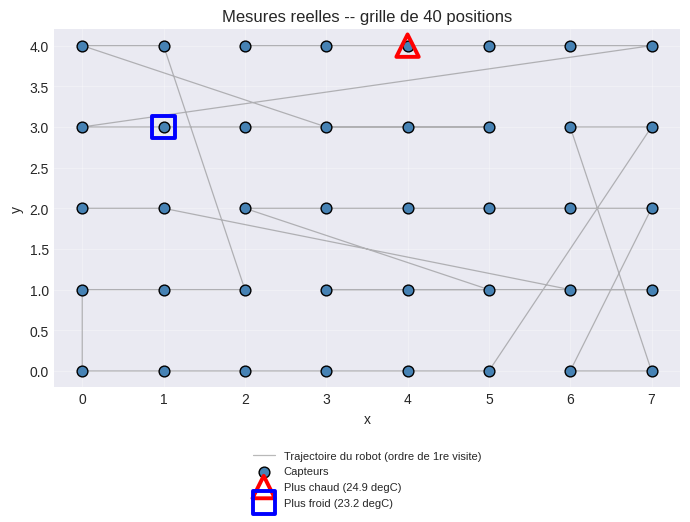

In [9]:
# --- Mesures reelles : capteurs, point le plus chaud/froid, trajectoire du robot
#     (repris de V3, section 9) ---
fig, ax = plt.subplots(figsize=(7, 6))
xs_pos = [p[0] for p in positions_uniques]
ys_pos = [p[1] for p in positions_uniques]

ordre_positions = (df_long.sort_values('t_sec')
                   .drop_duplicates(subset=['x', 'y'], keep='first')[['x', 'y']])
ax.plot(ordre_positions['x'], ordre_positions['y'], color='gray', lw=0.9, alpha=0.55,
        zorder=1, label='Trajectoire du robot (ordre de 1re visite)')
ax.scatter(xs_pos, ys_pos, c='steelblue', s=60, edgecolor='k', zorder=2, label='Capteurs')

temp_moy_xy = df_long.groupby(['x', 'y'])['temperature'].mean()
pos_chaude, pos_froide = temp_moy_xy.idxmax(), temp_moy_xy.idxmin()
ax.scatter(*pos_chaude, marker='^', s=260, facecolors='none', edgecolors='red', linewidths=2.8,
           zorder=5, label=f'Plus chaud ({temp_moy_xy.max():.1f} degC)')
ax.scatter(*pos_froide, marker='s', s=260, facecolors='none', edgecolors='blue', linewidths=2.8,
           zorder=5, label=f'Plus froid ({temp_moy_xy.min():.1f} degC)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=8)
ax.set_title(f'Mesures reelles -- grille de {len(positions_uniques)} positions')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10-11 — Visualisation du champ thermique prédit (2D et 3D)

Carte **complètement remplie** (aucune cellule blanche) : le modèle prédit une valeur pour
les 120 positions, y compris celles non couvertes par la trajectoire de démonstration. Les
positions réellement mesurées pour cette trajectoire restent visibles par-dessus (cercles
blancs).

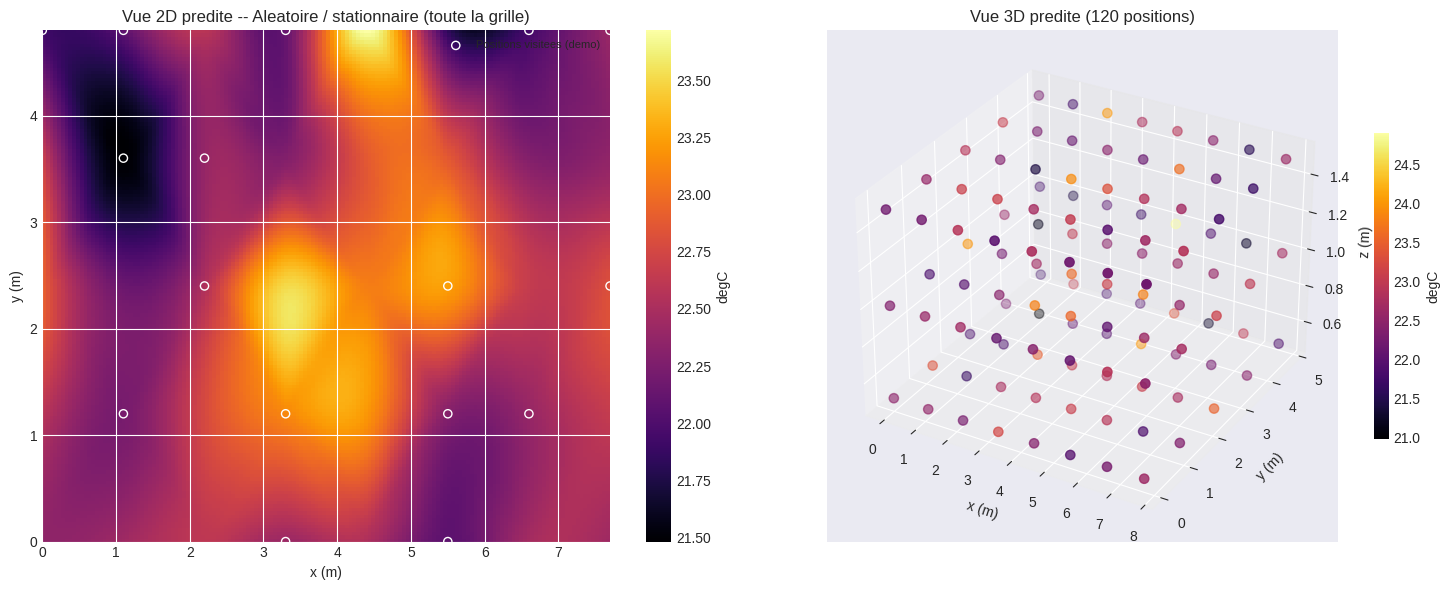

In [10]:
fig = plt.figure(figsize=(15, 6))

# --- Vue 2D (griddata cubic sur la grille DEJA complete -> pas de trou possible) ---
ax1 = fig.add_subplot(1, 2, 1)
agg_xy_pred = grille_pred.groupby(['x', 'y'])['predit'].mean().reset_index()
xs_m = agg_xy_pred['x'].values * ESPACEMENT_X
ys_m = agg_xy_pred['y'].values * ESPACEMENT_Y
ts_xy = agg_xy_pred['predit'].values
grid_x, grid_y = np.mgrid[xs_m.min():xs_m.max():150j, ys_m.min():ys_m.max():150j]
grid_t = griddata((xs_m, ys_m), ts_xy, (grid_x, grid_y), method='cubic')
im = ax1.imshow(grid_t.T, extent=(xs_m.min(), xs_m.max(), ys_m.min(), ys_m.max()),
                origin='lower', cmap='inferno', aspect='auto')
plt.colorbar(im, ax=ax1, label='degC')
ax1.scatter(agg_observe['x'] * ESPACEMENT_X, agg_observe['y'] * ESPACEMENT_Y,
            facecolors='none', edgecolors='white', s=35, linewidths=1.0, zorder=5,
            label='Positions visitees (demo)')
ax1.legend(fontsize=8)
ax1.set_title(f"Vue 2D predite -- {TRAJ_DEMO} / {PHASE_DEMO} (toute la grille)")
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')

# --- Vue 3D ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
xs3 = grille_pred['x'].values * ESPACEMENT_X
ys3 = grille_pred['y'].values * ESPACEMENT_Y
zs3 = grille_pred['z'].map(lambda z: ALTITUDES_Z[int(z)]).values
sc = ax2.scatter(xs3, ys3, zs3, c=grille_pred['predit'].values, cmap='inferno', s=45)
fig.colorbar(sc, ax=ax2, label='degC', shrink=0.6)
ax2.set_title('Vue 3D predite (120 positions)')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)'); ax2.set_zlabel('z (m)')

plt.tight_layout(); plt.show()


## 12 — Résultats principaux (R², RMSE, MAE)

Comparaison entre la carte prédite (toutes les 120 positions, y compris celles non visitées
par la trajectoire de démonstration) et la vérité terrain réelle disponible sur ces mêmes
120 positions. **Ce n'est pas un score de généralisation spatiale strict** (celui-ci est
établi rigoureusement dans V3 via un split spatial dédié, sections 12/13/17bis) : c'est une
vérification honnête de la qualité du remplissage pour ce scénario de démonstration précis.

In [11]:
verite_terrain = df_fusion[(df_fusion['heating_type'] == CHAUFF_DEMO) &
                            (df_fusion['trajectory_type'] == TRAJECTORY_TYPE_MESUREE) &
                            (df_fusion['phase'] == PHASE_DEMO)]
agg_verite = verite_terrain.groupby(['x', 'y', 'z'])['temperature'].mean().reset_index()

comparaison = grille_pred.merge(agg_verite, on=['x', 'y', 'z'], suffixes=('', '_reel'))
m = calculer_metriques(comparaison['temperature'].values, comparaison['predit'].values)
print(f"Trajectoire de demonstration : {TRAJ_DEMO} / {PHASE_DEMO}")
print(f"  R2   = {m['r2']:.4f}")
print(f"  RMSE = {m['rmse']:.3f} degC")
print(f"  MAE  = {m['mae']:.3f} degC")
print(f"  (n = {len(comparaison)} positions, dont {len(agg_observe)} reellement 'visitees' "
      f"et {len(comparaison) - len(agg_observe)} extrapolees par le modele)")


Trajectoire de demonstration : Aleatoire / stationnaire
  R2   = 0.5683
  RMSE = 0.537 degC
  MAE  = 0.433 degC
  (n = 120 positions, dont 16 reellement 'visitees' et 104 extrapolees par le modele)
